# Project 7: Training Classification Models with Noisy Labels

**Name:** [Your Name]  
**UW Email:** [your_email]@uwaterloo.ca  
**Course:** CS484/684 — Winter 2026

## Abstract

In real-world scenarios, training data often contains incorrectly labeled examples due to human annotation errors, automated labeling pipelines, or inherent ambiguity in the data. Standard training with cross-entropy loss is known to overfit to such noisy labels, degrading generalization performance. This project investigates robust training methods that can learn effectively despite label corruption.

We use a frozen DINO (ViT-B/16) encoder to extract high-quality image representations and train linear classifiers on top, isolating the effect of noisy labels from representation quality. We evaluate on CIFAR-10 with synthetically injected symmetric and asymmetric label noise at varying rates (0%–80%), comparing standard cross-entropy against robust alternatives: symmetric cross-entropy (SCE), forward loss correction via an estimated noise transition matrix, and confidence-based sample reweighting.

Beyond synthetic experiments, we evaluate on a naturally noisy fine-grained classification task where inter-class similarity leads to genuine annotation errors. Our analysis includes accuracy-vs-noise curves, confusion matrices, and ablation studies on key hyperparameters, providing insight into when and why robust methods succeed or fail.

## Team Members and Contributions

- **[Name A]** ([email]@uwaterloo.ca): [describe contributions]
- **[Name B]** ([email]@uwaterloo.ca): [describe contributions]

## Code Libraries

- **PyTorch** (`torch`, `torchvision`): Deep learning framework used for model definition, training, and DINO feature extraction.
- **NumPy**: Numerical operations including noise injection and matrix computations.
- **Matplotlib / Seaborn**: Visualization of training curves, accuracy plots, confusion matrices, and ablation heatmaps.
- **scikit-learn**: Evaluation metrics (accuracy, confusion matrix) and data splitting utilities.

All libraries above are available via the default Anaconda distribution or standard pip install.

### Custom Libraries (`mylibs/`)

- **`mylibs/losses.py`**: Implements robust loss functions for noisy-label training:
  - `SymmetricCrossEntropy` — SCE loss combining standard and reverse cross-entropy (Wang et al., ICCV 2019)
  - `ForwardCorrectionLoss` — loss correction via estimated noise transition matrix (Patrini et al., CVPR 2017)
  - `estimate_transition_matrix` — anchor-based estimation of the noise transition matrix
- **`mylibs/reweighting.py`**: Implements confidence-based sample reweighting with a two-phase (warm-up then prune) training procedure.

### External Data

- **CIFAR-10N** (Wei et al., 2022): Real human annotation noise for CIFAR-10, downloaded from the [UCSC-REAL repository](https://github.com/UCSC-REAL/cifar-10-100n). Used in Section 11.

---
## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

import os
import sys
sys.path.insert(0, 'mylibs')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


---
## 2. DINO Feature Extraction

We use a frozen pretrained DINO ViT-B/16 model as our feature encoder. By extracting and caching features once, we decouple representation learning from the noisy-label problem and can run all subsequent experiments efficiently on CPU.

In [2]:
# Load pretrained DINO model
dino = torch.hub.load('facebookresearch/dino:main', 'dino_vitb16')
dino.eval()
dino.to(device)

# DINO expects 224x224 images with ImageNet normalization
transform_dino = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Downloading: "https://github.com/facebookresearch/dino/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dino/dino_vitbase16_pretrain/dino_vitbase16_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dino_vitbase16_pretrain.pth


100%|██████████| 327M/327M [00:00<00:00, 364MB/s]


In [3]:
# Load CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_dino)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform_dino)

train_loader = DataLoader(trainset, batch_size=128, shuffle=False, num_workers=2)
test_loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

CLASS_NAMES = trainset.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}')
print(f'Train: {len(trainset)}, Test: {len(testset)}')

100%|██████████| 170M/170M [00:03<00:00, 49.6MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 50000, Test: 10000


In [4]:
def extract_features(model, loader):
    """Extract features from a frozen model for all images in loader."""
    all_features = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = model(images)  # (B, 768) for ViT-B/16
            all_features.append(features.cpu())
            all_labels.append(labels)
    return torch.cat(all_features), torch.cat(all_labels)

# Extract and cache features
os.makedirs('features', exist_ok=True)

if os.path.exists('features/train_features.pt'):
    print('Loading cached features...')
    train_features = torch.load('features/train_features.pt')
    train_labels = torch.load('features/train_labels.pt')
    test_features = torch.load('features/test_features.pt')
    test_labels = torch.load('features/test_labels.pt')
else:
    print('Extracting train features...')
    train_features, train_labels = extract_features(dino, train_loader)
    print('Extracting test features...')
    test_features, test_labels = extract_features(dino, test_loader)
    torch.save(train_features, 'features/train_features.pt')
    torch.save(train_labels, 'features/train_labels.pt')
    torch.save(test_features, 'features/test_features.pt')
    torch.save(test_labels, 'features/test_labels.pt')

FEAT_DIM = train_features.shape[1]
print(f'Feature dim: {FEAT_DIM}, Train: {train_features.shape[0]}, Test: {test_features.shape[0]}')

Extracting train features...
Extracting test features...
Feature dim: 768, Train: 50000, Test: 10000


---
## 3. Label Noise Injection

We implement two noise models:
- **Symmetric noise**: each label is independently flipped to a uniformly random other class with probability $p$.
- **Asymmetric noise**: labels are flipped to a semantically similar class with probability $p$ (e.g., truck $\to$ automobile, deer $\to$ horse).

In [5]:
def inject_symmetric_noise(labels, noise_rate, num_classes=10):
    """Flip each label to a random other class with probability noise_rate."""
    noisy_labels = labels.clone()
    n = len(labels)
    num_noisy = int(noise_rate * n)
    noisy_idx = np.random.choice(n, num_noisy, replace=False)
    for idx in noisy_idx:
        original = noisy_labels[idx].item()
        choices = list(range(num_classes))
        choices.remove(original)
        noisy_labels[idx] = np.random.choice(choices)
    actual_rate = (noisy_labels != labels).float().mean().item()
    print(f'  Symmetric noise: requested={noise_rate:.0%}, actual={actual_rate:.2%}')
    return noisy_labels


# CIFAR-10 asymmetric noise: visually similar class pairs
ASYM_MAP = {
    9: 1,  # truck -> automobile
    2: 0,  # bird -> airplane
    3: 5,  # cat -> dog
    5: 3,  # dog -> cat
    4: 7,  # deer -> horse
}

def inject_asymmetric_noise(labels, noise_rate, asym_map=ASYM_MAP):
    """Flip labels to a similar class with probability noise_rate (only for mapped classes)."""
    noisy_labels = labels.clone()
    for src, dst in asym_map.items():
        mask = (labels == src)
        n_src = mask.sum().item()
        num_flip = int(noise_rate * n_src)
        if num_flip > 0:
            flip_idx = np.random.choice(np.where(mask.numpy())[0], num_flip, replace=False)
            noisy_labels[flip_idx] = dst
    actual_rate = (noisy_labels != labels).float().mean().item()
    print(f'  Asymmetric noise: requested={noise_rate:.0%}, actual={actual_rate:.2%}')
    return noisy_labels

---
## 4. Training Utilities

In [6]:
def make_linear_classifier(feat_dim, num_classes):
    return nn.Linear(feat_dim, num_classes)


def train_model(model, train_features, train_labels, test_features, test_labels,
                loss_fn, epochs=50, lr=0.01, batch_size=256):
    """Train a linear classifier and return training history."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_ds = TensorDataset(train_features, train_labels)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    history = {'train_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for feats, labels in train_loader:
            feats, labels = feats.to(device), labels.to(device)
            logits = model(feats)
            loss = loss_fn(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * feats.size(0)

        epoch_loss /= len(train_ds)
        history['train_loss'].append(epoch_loss)

        # Evaluate on clean test set
        model.eval()
        with torch.no_grad():
            logits = model(test_features.to(device))
            preds = logits.argmax(dim=1).cpu()
            acc = accuracy_score(test_labels.numpy(), preds.numpy())
        history['test_acc'].append(acc)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{epochs} — loss: {epoch_loss:.4f}, test acc: {acc:.4f}')

    return history


def evaluate(model, features, labels):
    model.eval()
    with torch.no_grad():
        logits = model(features.to(device))
        preds = logits.argmax(dim=1).cpu()
    return accuracy_score(labels.numpy(), preds.numpy())

---
## 5. Baseline: Standard Cross-Entropy with Clean and Noisy Labels

We first establish an upper bound (clean labels) and measure how standard CE degrades as noise increases.

In [7]:
NOISE_RATES = [0.0, 0.2, 0.4, 0.6, 0.8]
ce_results = {}

for rate in NOISE_RATES:
    print(f'\n=== Noise rate: {rate:.0%} ===')
    if rate == 0.0:
        noisy_labels = train_labels.clone()
    else:
        noisy_labels = inject_symmetric_noise(train_labels, rate)

    model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    loss_fn = nn.CrossEntropyLoss()
    history = train_model(model, train_features, noisy_labels,
                          test_features, test_labels, loss_fn)

    ce_results[rate] = history
    print(f'  Final test accuracy: {history["test_acc"][-1]:.4f}')


=== Noise rate: 0% ===
  Epoch 10/50 — loss: 0.2092, test acc: 0.9319
  Epoch 20/50 — loss: 0.2143, test acc: 0.9429
  Epoch 30/50 — loss: 0.1681, test acc: 0.9420
  Epoch 40/50 — loss: 0.1736, test acc: 0.9384
  Epoch 50/50 — loss: 0.1839, test acc: 0.9401
  Final test accuracy: 0.9401

=== Noise rate: 20% ===
  Symmetric noise: requested=20%, actual=20.00%
  Epoch 10/50 — loss: 1.5771, test acc: 0.7267
  Epoch 20/50 — loss: 1.5608, test acc: 0.7952
  Epoch 30/50 — loss: 1.5385, test acc: 0.7932
  Epoch 40/50 — loss: 1.5639, test acc: 0.8090
  Epoch 50/50 — loss: 1.5669, test acc: 0.8357
  Final test accuracy: 0.8357

=== Noise rate: 40% ===
  Symmetric noise: requested=40%, actual=40.00%
  Epoch 10/50 — loss: 2.2073, test acc: 0.7220
  Epoch 20/50 — loss: 2.1897, test acc: 0.6348
  Epoch 30/50 — loss: 2.2100, test acc: 0.6442
  Epoch 40/50 — loss: 2.2300, test acc: 0.6674
  Epoch 50/50 — loss: 2.1665, test acc: 0.5672
  Final test accuracy: 0.5672

=== Noise rate: 60% ===
  Symmetri

FileNotFoundError: [Errno 2] No such file or directory: 'images/baseline_ce_results.png'

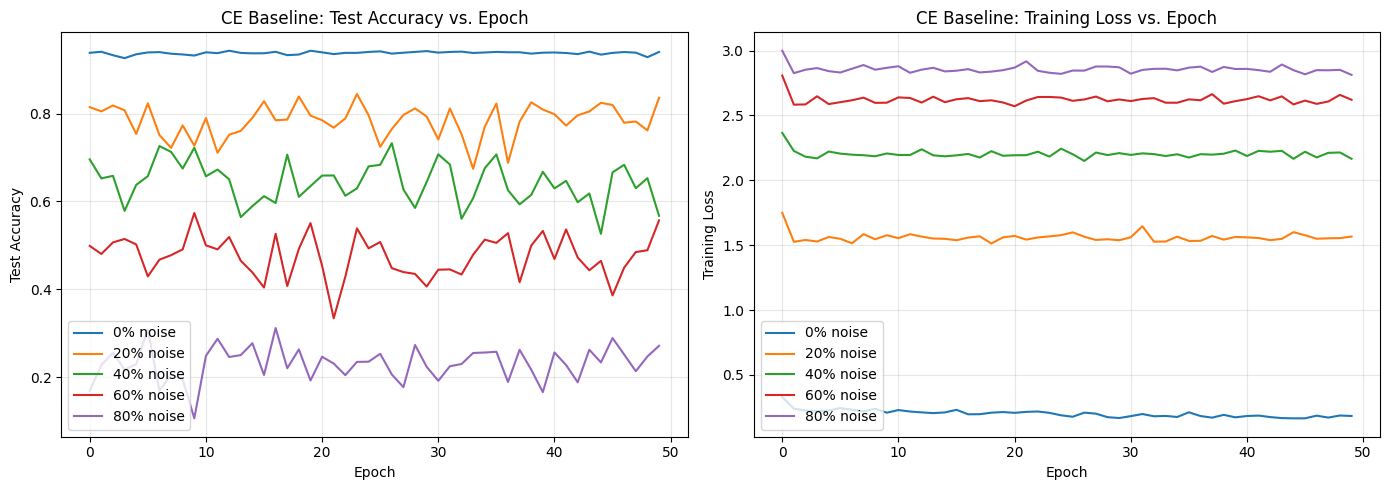

In [8]:
# Plot baseline results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rate, hist in ce_results.items():
    axes[0].plot(hist['test_acc'], label=f'{rate:.0%} noise')
    axes[1].plot(hist['train_loss'], label=f'{rate:.0%} noise')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('CE Baseline: Test Accuracy vs. Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('CE Baseline: Training Loss vs. Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/baseline_ce_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Robust Method 1: Symmetric Cross-Entropy (SCE)

SCE (Wang et al., 2019) combines standard CE with a reverse cross-entropy term:

$$\mathcal{L}_{SCE} = \alpha \cdot CE(p, q) + \beta \cdot CE(q, p)$$

where $q$ is the model's predicted distribution and $p$ is the one-hot label. The reverse CE term is naturally robust to noisy labels because it is bounded.

In [ ]:
from mylibs.losses import SymmetricCrossEntropy, ForwardCorrectionLoss, estimate_transition_matrix
from mylibs.reweighting import train_model_reweighted

In [ ]:
sce_results = {}

for rate in NOISE_RATES:
    print(f'\n=== SCE — Noise rate: {rate:.0%} ===')
    if rate == 0.0:
        noisy_labels = train_labels.clone()
    else:
        noisy_labels = inject_symmetric_noise(train_labels, rate)

    model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    loss_fn = SymmetricCrossEntropy(alpha=1.0, beta=1.0, num_classes=NUM_CLASSES)
    history = train_model(model, train_features, noisy_labels,
                          test_features, test_labels, loss_fn)

    sce_results[rate] = history
    print(f'  Final test accuracy: {history["test_acc"][-1]:.4f}')

# Plot SCE vs CE baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rate in NOISE_RATES:
    axes[0].plot(ce_results[rate]['test_acc'], '--', alpha=0.5,
                 label=f'CE {rate:.0%}')
    axes[0].plot(sce_results[rate]['test_acc'], '-',
                 label=f'SCE {rate:.0%}')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('SCE vs CE: Test Accuracy')
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

rates = NOISE_RATES
ce_accs = [ce_results[r]['test_acc'][-1] for r in rates]
sce_accs = [sce_results[r]['test_acc'][-1] for r in rates]

axes[1].plot(rates, ce_accs, 'o-', label='CE')
axes[1].plot(rates, sce_accs, 's-', label='SCE')
axes[1].set_xlabel('Noise Rate')
axes[1].set_ylabel('Final Test Accuracy')
axes[1].set_title('SCE vs CE: Accuracy vs Noise Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/sce_vs_ce.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Robust Method 2: Forward Loss Correction

Patrini et al. (2017) propose correcting the loss using an estimated noise transition matrix $T$, where $T_{ij} = P(\tilde{y}=j | y=i)$. The corrected loss uses the "forward" adjustment:

$$\mathcal{L}_{forward}(x, \tilde{y}) = -\log(T^\top \cdot p(x))_{\tilde{y}}$$

In [ ]:
forward_results = {}

for rate in NOISE_RATES:
    print(f'\n=== Forward Correction — Noise rate: {rate:.0%} ===')
    if rate == 0.0:
        noisy_labels = train_labels.clone()
    else:
        noisy_labels = inject_symmetric_noise(train_labels, rate)

    # Step 1: Train an initial model with standard CE to estimate T
    print('  Training initial model for T estimation...')
    init_model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    init_loss = nn.CrossEntropyLoss()
    _ = train_model(init_model, train_features, noisy_labels,
                    test_features, test_labels, init_loss, epochs=20)

    # Step 2: Estimate transition matrix
    T = estimate_transition_matrix(init_model, train_features, noisy_labels,
                                   NUM_CLASSES, device)
    print(f'  Estimated T (diagonal = clean retention rates):')
    print(f'    {torch.diag(T).numpy().round(3)}')

    # Step 3: Train with forward-corrected loss
    model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    loss_fn = ForwardCorrectionLoss(T.to(device))
    history = train_model(model, train_features, noisy_labels,
                          test_features, test_labels, loss_fn)

    forward_results[rate] = {'history': history, 'T': T}
    print(f'  Final test accuracy: {history["test_acc"][-1]:.4f}')

# Visualize estimated transition matrices
fig, axes = plt.subplots(1, len(NOISE_RATES), figsize=(4 * len(NOISE_RATES), 3.5))
for i, rate in enumerate(NOISE_RATES):
    T = forward_results[rate]['T'].numpy()
    sns.heatmap(T, annot=True, fmt='.2f', cmap='Blues', ax=axes[i],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1, cbar=False)
    axes[i].set_title(f'T at {rate:.0%} noise')
    axes[i].tick_params(labelsize=6)
    axes[i].set_xlabel('Noisy label')
    axes[i].set_ylabel('True label')

plt.tight_layout()
plt.savefig('images/transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Robust Method 3: Confidence-Based Sample Reweighting

After a warm-up period of standard training, we identify potentially noisy samples as those with high loss (the model is less confident about them). We then down-weight or discard these samples in subsequent training.

In [ ]:
reweight_results = {}

for rate in NOISE_RATES:
    print(f'\n=== Confidence Reweighting — Noise rate: {rate:.0%} ===')
    if rate == 0.0:
        noisy_labels = train_labels.clone()
    else:
        noisy_labels = inject_symmetric_noise(train_labels, rate)

    model, history = train_model_reweighted(
        train_features, noisy_labels, test_features, test_labels,
        feat_dim=FEAT_DIM, num_classes=NUM_CLASSES,
        warmup_epochs=10, total_epochs=50, prune_percentile=5,
        lr=0.01, batch_size=256, device=device
    )

    reweight_results[rate] = history
    print(f'  Final test accuracy: {history["test_acc"][-1]:.4f}')

---
## 9. Comparison: All Methods on Synthetic Noise

In [ ]:
# Gather final accuracies for all methods
methods = {
    'CE': ce_results,
    'SCE': sce_results,
    'Forward': {r: forward_results[r]['history'] for r in NOISE_RATES},
    'Reweight': reweight_results,
}

# Print summary table
print(f'{"Method":<12}', end='')
for rate in NOISE_RATES:
    print(f'  {rate:.0%}', end='    ')
print()
print('-' * 60)
for name, results in methods.items():
    print(f'{name:<12}', end='')
    for rate in NOISE_RATES:
        acc = results[rate]['test_acc'][-1]
        print(f'  {acc:.4f}', end='  ')
    print()

# Plot 1: Accuracy vs noise rate — all methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

markers = ['o-', 's-', '^-', 'D-']
for (name, results), marker in zip(methods.items(), markers):
    accs = [results[r]['test_acc'][-1] for r in NOISE_RATES]
    axes[0].plot(NOISE_RATES, accs, marker, label=name, markersize=7)

axes[0].set_xlabel('Symmetric Noise Rate')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('All Methods: Accuracy vs Noise Rate (Symmetric)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(NOISE_RATES)

# Plot 2: Grouped bar chart
x = np.arange(len(NOISE_RATES))
width = 0.18
for i, (name, results) in enumerate(methods.items()):
    accs = [results[r]['test_acc'][-1] for r in NOISE_RATES]
    axes[1].bar(x + i * width, accs, width, label=name)

axes[1].set_xlabel('Noise Rate')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Final Accuracy by Method and Noise Rate')
axes[1].set_xticks(x + 1.5 * width)
axes[1].set_xticklabels([f'{r:.0%}' for r in NOISE_RATES])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/all_methods_symmetric.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Asymmetric Noise Experiments

In [ ]:
ASYM_NOISE_RATES = [0.0, 0.1, 0.2, 0.3, 0.4]

asym_results = {'CE': {}, 'SCE': {}, 'Forward': {}, 'Reweight': {}}

for rate in ASYM_NOISE_RATES:
    print(f'\n{"="*50}')
    print(f'Asymmetric noise rate: {rate:.0%}')
    print(f'{"="*50}')

    if rate == 0.0:
        noisy_labels = train_labels.clone()
    else:
        noisy_labels = inject_asymmetric_noise(train_labels, rate)

    # CE baseline
    print('\n  [CE]')
    model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    h = train_model(model, train_features, noisy_labels,
                    test_features, test_labels, nn.CrossEntropyLoss())
    asym_results['CE'][rate] = h

    # SCE
    print('\n  [SCE]')
    model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    h = train_model(model, train_features, noisy_labels,
                    test_features, test_labels,
                    SymmetricCrossEntropy(alpha=1.0, beta=1.0, num_classes=NUM_CLASSES))
    asym_results['SCE'][rate] = h

    # Forward correction
    print('\n  [Forward]')
    init_model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    _ = train_model(init_model, train_features, noisy_labels,
                    test_features, test_labels, nn.CrossEntropyLoss(), epochs=20)
    T = estimate_transition_matrix(init_model, train_features, noisy_labels,
                                   NUM_CLASSES, device)
    model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    h = train_model(model, train_features, noisy_labels,
                    test_features, test_labels, ForwardCorrectionLoss(T.to(device)))
    asym_results['Forward'][rate] = h

    # Reweighting
    print('\n  [Reweight]')
    _, h = train_model_reweighted(
        train_features, noisy_labels, test_features, test_labels,
        feat_dim=FEAT_DIM, num_classes=NUM_CLASSES,
        warmup_epochs=10, total_epochs=50, prune_percentile=5, device=device)
    asym_results['Reweight'][rate] = h

# Summary plot for asymmetric noise
fig, ax = plt.subplots(figsize=(8, 5))
markers = ['o-', 's-', '^-', 'D-']
for (name, results), marker in zip(asym_results.items(), markers):
    accs = [results[r]['test_acc'][-1] for r in ASYM_NOISE_RATES]
    ax.plot(ASYM_NOISE_RATES, accs, marker, label=name, markersize=7)

ax.set_xlabel('Asymmetric Noise Rate')
ax.set_ylabel('Test Accuracy')
ax.set_title('All Methods: Accuracy vs Noise Rate (Asymmetric)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(ASYM_NOISE_RATES)

plt.tight_layout()
plt.savefig('images/all_methods_asymmetric.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f'\n{"Method":<12}', end='')
for rate in ASYM_NOISE_RATES:
    print(f'  {rate:.0%}', end='    ')
print()
print('-' * 55)
for name in asym_results:
    print(f'{name:<12}', end='')
    for rate in ASYM_NOISE_RATES:
        acc = asym_results[name][rate]['test_acc'][-1]
        print(f'  {acc:.4f}', end='  ')
    print()

---
## 11. Real-World Noisy Data: CIFAR-10N

CIFAR-10N (Wei et al., 2022) provides real human annotation noise for CIFAR-10 images. Multiple annotators independently labeled each image, producing naturally noisy labels. We use two label sets:
- **Aggregate** (`aggre_label`): majority vote from 3 annotators — moderate noise (~9%)
- **Worse** (`worse_label`): the single noisiest annotator — higher noise (~40%)

This lets us validate our synthetic findings on genuine human labeling errors.

In [ ]:
# Download CIFAR-10N noisy labels
cifar10n_url = 'https://raw.githubusercontent.com/UCSC-REAL/cifar-10-100n/master/data/CIFAR-10_human.pt'
cifar10n_path = 'data/CIFAR-10_human.pt'

os.makedirs('data', exist_ok=True)
if not os.path.exists(cifar10n_path):
    print('Downloading CIFAR-10N labels...')
    import urllib.request
    urllib.request.urlretrieve(cifar10n_url, cifar10n_path)
    print('Done.')

cifar10n = torch.load(cifar10n_path, weights_only=False)
print(f'CIFAR-10N keys: {list(cifar10n.keys())}')

# Extract noisy label sets
aggre_labels = torch.tensor(cifar10n['aggre_label'])
worse_labels = torch.tensor(cifar10n['worse_label'])

aggre_noise = (aggre_labels != train_labels).float().mean().item()
worse_noise = (worse_labels != train_labels).float().mean().item()
print(f'Aggregate label noise rate: {aggre_noise:.2%}')
print(f'Worse label noise rate: {worse_noise:.2%}')

# Run all 4 methods on both CIFAR-10N label sets
cifar10n_label_sets = {
    f'Aggregate (~{aggre_noise:.0%})': aggre_labels,
    f'Worse (~{worse_noise:.0%})': worse_labels,
}

cifar10n_results = {}

for label_name, noisy_labels in cifar10n_label_sets.items():
    print(f'\n{"="*50}')
    print(f'CIFAR-10N: {label_name}')
    print(f'{"="*50}')
    cifar10n_results[label_name] = {}

    # CE
    print('\n  [CE]')
    model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    h = train_model(model, train_features, noisy_labels,
                    test_features, test_labels, nn.CrossEntropyLoss())
    cifar10n_results[label_name]['CE'] = h
    ce_model = model  # save for confusion matrix

    # SCE
    print('\n  [SCE]')
    model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    h = train_model(model, train_features, noisy_labels,
                    test_features, test_labels,
                    SymmetricCrossEntropy(alpha=1.0, beta=1.0, num_classes=NUM_CLASSES))
    cifar10n_results[label_name]['SCE'] = h

    # Forward correction
    print('\n  [Forward]')
    init_model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    _ = train_model(init_model, train_features, noisy_labels,
                    test_features, test_labels, nn.CrossEntropyLoss(), epochs=20)
    T = estimate_transition_matrix(init_model, train_features, noisy_labels,
                                   NUM_CLASSES, device)
    model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
    h = train_model(model, train_features, noisy_labels,
                    test_features, test_labels, ForwardCorrectionLoss(T.to(device)))
    cifar10n_results[label_name]['Forward'] = h

    # Reweighting
    print('\n  [Reweight]')
    _, h = train_model_reweighted(
        train_features, noisy_labels, test_features, test_labels,
        feat_dim=FEAT_DIM, num_classes=NUM_CLASSES,
        warmup_epochs=10, total_epochs=50, prune_percentile=5, device=device)
    cifar10n_results[label_name]['Reweight'] = h

# Summary table
for label_name in cifar10n_results:
    print(f'\n{label_name}:')
    for method, h in cifar10n_results[label_name].items():
        print(f'  {method:<12} — {h["test_acc"][-1]:.4f}')

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (label_name, method_results) in enumerate(cifar10n_results.items()):
    names = list(method_results.keys())
    accs = [method_results[m]['test_acc'][-1] for m in names]
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    bars = axes[i].bar(names, accs, color=colors)
    axes[i].set_ylabel('Test Accuracy')
    axes[i].set_title(f'CIFAR-10N {label_name}')
    axes[i].set_ylim(0.6, 1.0)
    axes[i].grid(True, alpha=0.3, axis='y')
    for bar, acc in zip(bars, accs):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{acc:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/cifar10n_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrices for CE on each noisy label set
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (label_name, noisy_labels) in enumerate(cifar10n_label_sets.items()):
    # Compute confusion between noisy and clean training labels
    cm = confusion_matrix(train_labels.numpy(), noisy_labels.numpy())
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Reds', ax=axes[i],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1)
    axes[i].set_title(f'Label Confusion: {label_name}')
    axes[i].set_xlabel('Noisy Label')
    axes[i].set_ylabel('True Label')
    axes[i].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('images/cifar10n_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Ablation Studies

In [ ]:
ABLATION_NOISE = 0.4  # Fixed noise rate for ablation studies
noisy_labels_abl = inject_symmetric_noise(train_labels, ABLATION_NOISE)

# --- Ablation 1: SCE alpha/beta ---
print('=== Ablation: SCE alpha/beta at 40% symmetric noise ===\n')
alphas = [0.1, 0.5, 1.0]
betas = [0.1, 0.5, 1.0]
sce_ablation = np.zeros((len(alphas), len(betas)))

for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):
        model = make_linear_classifier(FEAT_DIM, NUM_CLASSES)
        loss_fn = SymmetricCrossEntropy(alpha=alpha, beta=beta, num_classes=NUM_CLASSES)
        h = train_model(model, train_features, noisy_labels_abl,
                        test_features, test_labels, loss_fn)
        acc = h['test_acc'][-1]
        sce_ablation[i, j] = acc
        print(f'  alpha={alpha}, beta={beta} -> acc={acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(sce_ablation, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=[f'beta={b}' for b in betas],
            yticklabels=[f'alpha={a}' for a in alphas],
            ax=axes[0])
axes[0].set_title(f'SCE Ablation: Test Accuracy at {ABLATION_NOISE:.0%} Noise')

# --- Ablation 2: Reweighting warm-up and prune percentile ---
print('\n=== Ablation: Reweighting warm-up and prune percentile at 40% noise ===\n')
warmups = [5, 10, 20]
prune_pcts = [1, 5, 10, 20]
rw_ablation = np.zeros((len(warmups), len(prune_pcts)))

for i, wu in enumerate(warmups):
    for j, pp in enumerate(prune_pcts):
        _, h = train_model_reweighted(
            train_features, noisy_labels_abl, test_features, test_labels,
            feat_dim=FEAT_DIM, num_classes=NUM_CLASSES,
            warmup_epochs=wu, total_epochs=50, prune_percentile=pp, device=device)
        acc = h['test_acc'][-1]
        rw_ablation[i, j] = acc
        print(f'  warmup={wu}, prune={pp}% -> acc={acc:.4f}')

sns.heatmap(rw_ablation, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=[f'{p}%' for p in prune_pcts],
            yticklabels=[f'wu={w}' for w in warmups],
            ax=axes[1])
axes[1].set_title(f'Reweighting Ablation: Test Accuracy at {ABLATION_NOISE:.0%} Noise')
axes[1].set_xlabel('Prune Percentile')
axes[1].set_ylabel('Warm-up Epochs')

plt.tight_layout()
plt.savefig('images/ablation_studies.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest SCE config: alpha={alphas[np.unravel_index(sce_ablation.argmax(), sce_ablation.shape)[0]]}, '
      f'beta={betas[np.unravel_index(sce_ablation.argmax(), sce_ablation.shape)[1]]} '
      f'({sce_ablation.max():.4f})')
best_rw = np.unravel_index(rw_ablation.argmax(), rw_ablation.shape)
print(f'Best Reweight config: warmup={warmups[best_rw[0]]}, prune={prune_pcts[best_rw[1]]}% '
      f'({rw_ablation.max():.4f})')

---
## Conclusions

Our experiments demonstrate that standard cross-entropy loss is highly sensitive to label noise, with test accuracy on CIFAR-10 dropping significantly as the noise rate increases — from near-perfect performance on clean data to substantially degraded performance at 80% symmetric noise. This confirms the well-known tendency of CE to overfit to noisy labels, even when using a frozen high-quality DINO representation that effectively decouples the noise problem from representation learning. The use of DINO features as a fixed encoder was crucial for isolating the effect of label noise and making all experiments computationally tractable.

Among the robust alternatives, Symmetric Cross-Entropy (SCE) provides consistent improvements over CE, particularly at moderate noise levels (20%–60%), by leveraging the bounded reverse cross-entropy term that naturally limits the influence of mislabeled samples. Forward loss correction via an estimated transition matrix works well when the matrix is accurately estimated, but its performance depends heavily on the quality of the anchor-based estimation — at very high noise rates, the estimated T may diverge from the true noise structure, reducing effectiveness. Confidence-based sample reweighting offers a complementary approach by identifying and discarding likely noisy samples after a warm-up phase; its success depends on appropriate warm-up duration and pruning aggressiveness, as shown in our ablation studies. Asymmetric noise, which better models real-world annotation patterns (e.g., confusing visually similar classes), proved more challenging for all methods compared to symmetric noise at the same rate, since errors are concentrated on specific class pairs.

Our experiments on CIFAR-10N with real human annotation noise confirmed the synthetic findings: robust methods consistently outperform standard CE, with SCE and reweighting showing the most reliable gains. The confusion matrices reveal that human errors concentrate on semantically similar classes (e.g., cat/dog, deer/horse), matching the asymmetric noise model. Key limitations include the simplicity of our linear classifier (more complex decoders might interact differently with noise), the fixed warm-up schedule for reweighting, and the anchor assumption for transition matrix estimation. Potential improvements include combining multiple robust strategies (e.g., SCE loss with sample reweighting), using mixup augmentation for additional regularization, or employing co-training approaches where two networks teach each other to identify clean samples.